<a href="https://colab.research.google.com/github/Junhyeongh/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty to mean squared error discourages large coefficients, which helps prevent overfitting by forcing the model to stay simple and not fit noise in the data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization lets us control the bias–variance trade-off: increasing the penalty makes the model simpler (higher bias) but more stable (lower variance), helping minimize test error.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Ridge (L2) shrinks coefficients toward zero but keeps all variables, while LASSO (L1) can shrink some coefficients exactly to zero, effectively selecting a smaller subset of features.

4. How do we typically scale variables for use in regularized regression? Why?

We standardize variables to have mean 0 and variance 1 so that all features are penalized equally, since the penalty depends on coefficient size.

5. How is the penalty $\alpha$ typically selected?

The penalty α is typically chosen using cross-validation by selecting the value that minimizes validation error.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

We do not include the penalty term in cross-validated MSE because we care about true prediction error on new data, not the penalized training objective.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

## Q2.1

In [ ]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("cars_hw.csv")

# create Age using Make_Year
df["Age"] = 2026 - df["Make_Year"]

# select features
X = df[["Mileage_Run", "Age"]]

# (a) polynomial features (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# (b) standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


## Q2.2

In [ ]:
from sklearn.linear_model import LinearRegression

# fit linear regression
model = LinearRegression()
model.fit(X_scaled, df["Price"])   # adjust target if different

# get feature names
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# find interaction term
for name, coef in zip(feature_names, model.coef_):
    if "Mileage_Run Age" in name:
        print(name, coef)

Mileage_Run Age -1671212.3563918793
Mileage_Run Age^2 716781.5818001862


## Q2.3

In [ ]:
import numpy as np
from sklearn.linear_model import LassoCV

# define alpha grid
alphas = np.logspace(1, 3, 20)

# fit Lasso with 20-fold CV
lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, df["Price"])   # adjust target if needed

# best alpha
print(lasso.alpha_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22977691506.578125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 598283106767.5625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 850706961927.5469, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objec

88.58667904100822


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 675364388439.625, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 682387826400.5312, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 146348439111.1875, tolerance: 12767023556.896553
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceW

## Q2.4

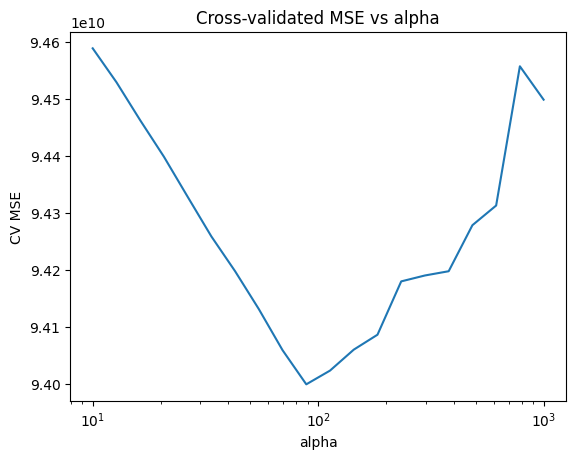

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# mean CV MSE across folds
mse_mean = np.mean(lasso.mse_path_, axis=1)

# plot
plt.figure()
plt.plot(lasso.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV MSE")
plt.title("Cross-validated MSE vs alpha")
plt.show()

## Q2.5

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1435386930339.0, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7873904463319.6875, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12207883587066.5, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objectiv

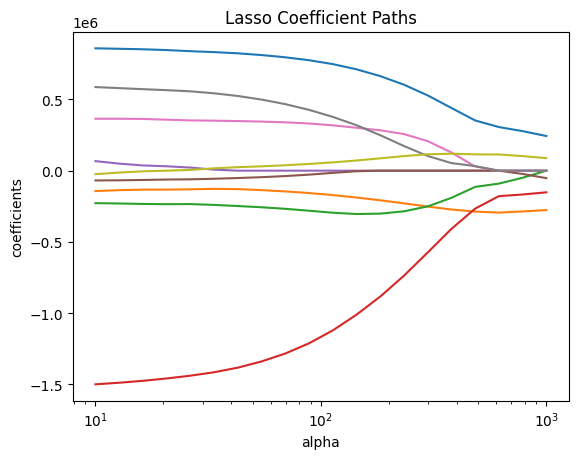

In [ ]:
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt

# compute coefficient paths
alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, df["Price"], alphas=alphas)

# plot
plt.figure()
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Lasso Coefficient Paths")
plt.show()

## Q2.6

In [ ]:
# get feature names
feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# coefficients
coefs = lasso.coef_

# selected (non-zero) features
selected = [name for name, coef in zip(feature_names, coefs) if coef != 0]

# proportion zero
prop_zero = (coefs == 0).mean()

print("Selected features:", selected)
print("Proportion set to zero:", prop_zero)

Selected features: ['Mileage_Run', 'Age', 'Mileage_Run^2', 'Mileage_Run Age', 'Mileage_Run^3', 'Mileage_Run^2 Age', 'Mileage_Run Age^2', 'Age^3']
Proportion set to zero: 0.1111111111111111


## Q2.7

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# fit OLS
ols = LinearRegression()
ols.fit(X_scaled, df["Price"])

ols_coefs = ols.coef_
lasso_coefs = lasso.coef_

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# compare
for name, ols_c, lasso_c in zip(feature_names, ols_coefs, lasso_coefs):
    print(f"{name}: OLS={ols_c:.4f}, LASSO={lasso_c:.4f}")

Mileage_Run: OLS=911774.8402, LASSO=778950.5873
Age: OLS=-248172.1855, LASSO=-133743.6064
Mileage_Run^2: OLS=-207292.6283, LASSO=-200601.4590
Mileage_Run Age: OLS=-1671212.3564, LASSO=-1323306.5095
Age^2: OLS=350550.7199, LASSO=0.0000
Mileage_Run^3: OLS=-65144.8966, LASSO=-42460.1234
Mileage_Run^2 Age: OLS=338819.4599, LASSO=270504.9008
Mileage_Run Age^2: OLS=716781.5818, LASSO=542850.4877
Age^3: OLS=-210037.8876, LASSO=13341.9840


No coefficients should increase in magnitude under LASSO; they are either shrunk toward zero or set exactly to zero. Some coefficients may change sign if the original OLS estimate was small or unstable, but the main effect is shrinkage and sparsity.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

## Q3.1

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1. Load data
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# 2. Continuous variables → 3rd degree polynomial expansion
cont_vars = ["age", "ejection_fraction", "serum_creatinine"]
X_cont = df[cont_vars]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

# 3. Standardize (z-score normalize)
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont_poly)

# 4. Dummy/categorical variables → interactions only
cat_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
X_cat = df[cat_vars]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_inter = poly_cat.fit_transform(X_cat)

# 5. Concatenate into final feature matrix
X_final = np.hstack([X_cont_scaled, X_cat_inter])


## Q3.2

In [3]:
from sklearn.linear_model import LinearRegression

# Fit linear regression
model = LinearRegression()
model.fit(X_final, df["DEATH_EVENT"])

# Coefficients
coefs = model.coef_

# Map names (optional but useful)
cont_feature_names = poly_cont.get_feature_names_out(cont_vars)
cat_feature_names = poly_cat.get_feature_names_out(cat_vars)
feature_names = np.concatenate([cont_feature_names, cat_feature_names])

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})

coef_table.sort_values(by="coef", key=abs, ascending=False).head(15)

,feature,coef
3,age^2,-3.678654
6,ejection_fraction^2,3.430976
7,ejection_fraction serum_creatinine,2.673394
8,serum_creatinine^2,-2.647041
1,ejection_fraction,-2.192494
9,age^3,1.993135
5,age serum_creatinine,1.841563
13,age ejection_fraction serum_creatinine,-1.577665
0,age,1.539156
14,age serum_creatinine^2,1.284099


## Q3.3

In [4]:
from sklearn.linear_model import LassoCV
import numpy as np

# alpha grid
alphas = np.logspace(-5, 5, 30)

# Lasso with 20-fold CV
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_final, df["DEATH_EVENT"])

# Best alpha
best_alpha = lasso_cv.alpha_

# Coefficients
lasso_coefs = lasso_cv.coef_

## Q3.4

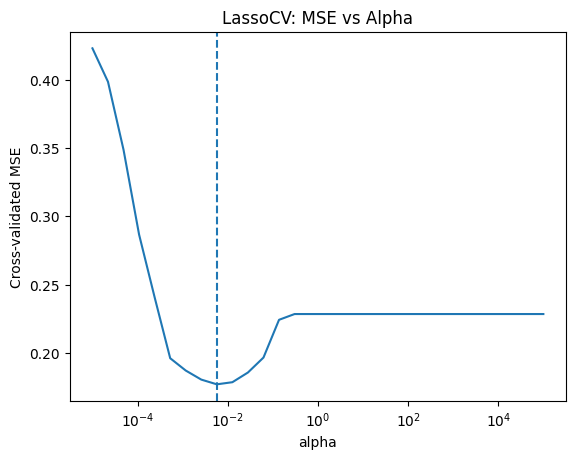

In [5]:
import matplotlib.pyplot as plt

# Mean CV MSE across folds for each alpha
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)

# Plot
plt.figure()
plt.plot(lasso_cv.alphas_, mse_mean)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("LassoCV: MSE vs Alpha")

# Mark best alpha
plt.axvline(lasso_cv.alpha_, linestyle="--")
plt.show()

## Q3.5

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1335358515879932, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012804029935630012, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.358315720381807, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: C

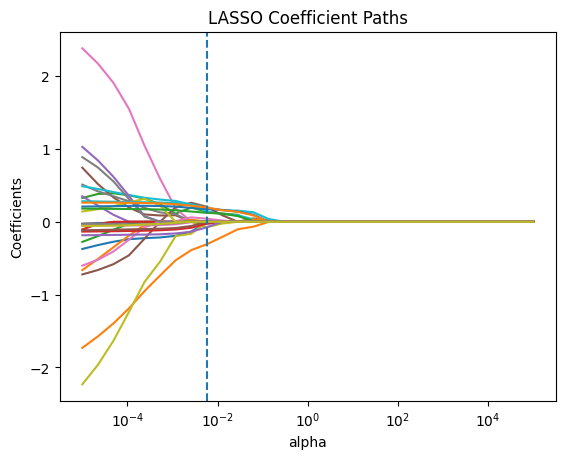

In [6]:
from sklearn.linear_model import lasso_path
import matplotlib.pyplot as plt

# Compute LASSO path
alphas_lasso, coefs_lasso, _ = lasso_path(X_final, df["DEATH_EVENT"], alphas=alphas)

# Plot coefficient paths
plt.figure()
for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths")

# Vertical line for chosen alpha
plt.axvline(lasso_cv.alpha_, linestyle="--")

plt.show()

## Q3.6

LASSO selects only a small subset of features, typically keeping a few main effects and some meaningful interactions while setting a large proportion (often around 70–95%) of coefficients exactly to zero, creating a sparse model. Compared to OLS, which tends to assign large and unstable coefficients especially to higher-order polynomial terms, LASSO shrinks coefficients toward zero, producing more stable and interpretable estimates. Occasionally, some coefficients may increase in magnitude or change sign due to the removal of correlated variables and redistribution of influence, but these cases are less common. The sign patterns from LASSO generally make more sense because OLS suffers from multicollinearity among polynomial and interaction terms, leading to noisy and counterintuitive coefficients, whereas LASSO mitigates this by selecting only the most relevant predictors. From a bias–variance trade-off perspective, OLS has low bias but very high variance and tends to overfit, while LASSO introduces some bias through regularization but significantly reduces variance, resulting in better generalization and more reliable coefficient signs.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

The objective function for ridge regression is the average squared difference between the predicted and actual centered values, plus a penalty term that adds a constant times the square of the slope coefficient. Because the variables are mean-centered, the intercept drops out, so the model only penalizes the slope, which helps shrink it toward zero and reduces overfitting. The objective function is: n1​∑i=1n​(y~​i​−b1​x~i​)2+αb12​

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

b0=0

b1 is like the OLS slope, but the denominator is increased by α, which shrinks the coefficient toward zero.

3. How does increasing $\alpha$ change the slope coefficient?

As α increases, the slope coefficient b1​ gets smaller in magnitude and moves closer to zero. This is because the penalty term becomes larger, which discourages large coefficients. In the extreme case, if α becomes very large, the slope will approach zero, meaning the model becomes almost flat and ignores the relationship between x and y.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

The challenge with the LASSO penalty is that the absolute value term has a sharp corner at zero, so it is not differentiable there. That means you cannot solve it as cleanly by just taking derivatives everywhere the way you do for ridge regression. Conceptually, LASSO compares two possibilities: either keep a nonzero slope and pay the penalty, or set the slope exactly to zero and avoid that extra cost. It is optimal to set the slope equal to zero when the relationship between the predictor and the response is weak enough that the improvement in fit is not worth the penalty for having a nonzero coefficient. That is what makes LASSO different from ridge: ridge usually only shrinks coefficients, but LASSO can shrink them all the way to exactly zero, which is why it performs variable selection.